# SE4050 – Deep Learning | Lab 1 – Task 2
Au Nanoparticle Dataset Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

## Load the dataset

The cell below uses `Au_nanoparticle_dataset.csv` if it already exists next to the notebook or under `data/`. Otherwise (e.g. a fresh Google Colab session) it downloads the file automatically from the lab's Google Drive folder.

In [4]:
from pathlib import Path
import subprocess
import sys

DRIVE_FILE_ID = "12u_T3ZSRkKwHM8msfDe9OdEmhZmvT6Eo"

candidates = [
    Path("data/Au_nanoparticle_dataset.csv"),
    Path("Au_nanoparticle_dataset.csv"),
    Path("/content/Au_nanoparticle_dataset.csv"),
]

csv_path = next((p for p in candidates if p.exists()), None)

if csv_path is None:
    # Not found locally (e.g. fresh Colab session) -> fetch from the lab Drive folder
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
    import gdown

    gdown.download(id=DRIVE_FILE_ID, output="Au_nanoparticle_dataset.csv", quiet=False)
    csv_path = Path("Au_nanoparticle_dataset.csv")

df = pd.read_csv(csv_path)
print("Loaded:", csv_path.resolve())
print("Shape:", df.shape)
df.head()

Downloading...
From: https://drive.google.com/uc?id=12u_T3ZSRkKwHM8msfDe9OdEmhZmvT6Eo
To: /content/Au_nanoparticle_dataset.csv
100%|██████████| 2.43M/2.43M [00:00<00:00, 15.1MB/s]


Loaded: /content/Au_nanoparticle_dataset.csv
Shape: (4000, 185)


,ID,T,tau,time,N_total,N_bulk,N_surface,Volume,R_min,R_max,...,q6q6_S14,q6q6_S15,q6q6_S16,q6q6_S17,q6q6_S18,q6q6_S19,q6q6_S20,q6q6_S20+,Total_E,Formation_E
0,1,273,0.000025,1,1599,1014,585,2.710000e-26,15.5898,19.4516,...,0,0,0,0,0,0,0,0,-5908.6345,343.4555
1,2,273,0.000025,2,1642,1034,608,2.780000e-26,15.3996,24.1755,...,0,0,0,0,0,0,0,0,-6035.4034,384.8166
2,3,273,0.000025,3,4637,3365,1272,7.850000e-26,21.9199,31.0305,...,0,0,0,0,0,0,0,0,-17330.1660,800.5040
3,4,273,0.000025,4,7189,5292,1897,1.220000e-25,23.2542,37.8795,...,0,0,0,0,0,0,0,0,-26937.2010,1171.7890
4,5,273,0.000025,5,11004,8508,2496,1.860000e-25,27.1200,39.7614,...,0,0,0,0,0,0,0,0,-41427.9010,1597.7390


## 1. Filter columns: N_total, N_bulk, N_surface, R_avg

In [5]:
features = ["N_total", "N_bulk", "N_surface", "R_avg"]
new_df = df[features].copy()
print("Filtered dataframe shape:", new_df.shape)
print("Columns:", list(new_df.columns))

Filtered dataframe shape: (4000, 4)
Columns: ['N_total', 'N_bulk', 'N_surface', 'R_avg']


## 2. Display the first 20 samples

In [6]:
new_df.head(20)

,N_total,N_bulk,N_surface,R_avg
0,1599,1014,585,17.3706
1,1642,1034,608,17.6061
2,4637,3365,1272,25.3692
3,7189,5292,1897,29.7011
4,11004,8508,2496,34.2831
5,13375,10768,2607,36.6334
6,13795,11155,2640,37.0108
7,13947,11304,2643,37.1672
8,14020,11357,2663,37.2103
9,14056,11389,2667,37.2467


## 3. Mean, standard deviation, and quartile values

In [7]:
# describe() includes mean, std, and quartiles (25%, 50%, 75%)
summary = new_df.describe()
display(summary)

print("\n--- Mean ---")
print(new_df.mean())

print("\n--- Standard Deviation ---")
print(new_df.std())

print("\n--- Quartiles (25%, 50%, 75%) ---")
print(new_df.quantile([0.25, 0.50, 0.75]))

,N_total,N_bulk,N_surface,R_avg
count,4000.000000,4000.000000,4000.00000,4000.000000
mean,3476.786500,2521.550250,955.23625,20.654363
std,3679.286769,2976.232459,721.87022,7.610716
min,236.000000,89.000000,137.00000,8.528600
25%,1061.000000,618.750000,437.00000,15.160725
50%,1867.000000,1199.000000,666.00000,18.629250
75%,4503.000000,3183.000000,1301.75000,25.525125
max,14277.000000,11580.000000,3190.00000,39.239200



--- Mean ---
N_total      3476.786500
N_bulk       2521.550250
N_surface     955.236250
R_avg          20.654363
dtype: float64

--- Standard Deviation ---
N_total      3679.286769
N_bulk       2976.232459
N_surface     721.870220
R_avg           7.610716
dtype: float64

--- Quartiles (25%, 50%, 75%) ---
      N_total   N_bulk  N_surface      R_avg
0.25   1061.0   618.75     437.00  15.160725
0.50   1867.0  1199.00     666.00  18.629250
0.75   4503.0  3183.00    1301.75  25.525125


## 4. Histograms of each feature (1×4 layout)

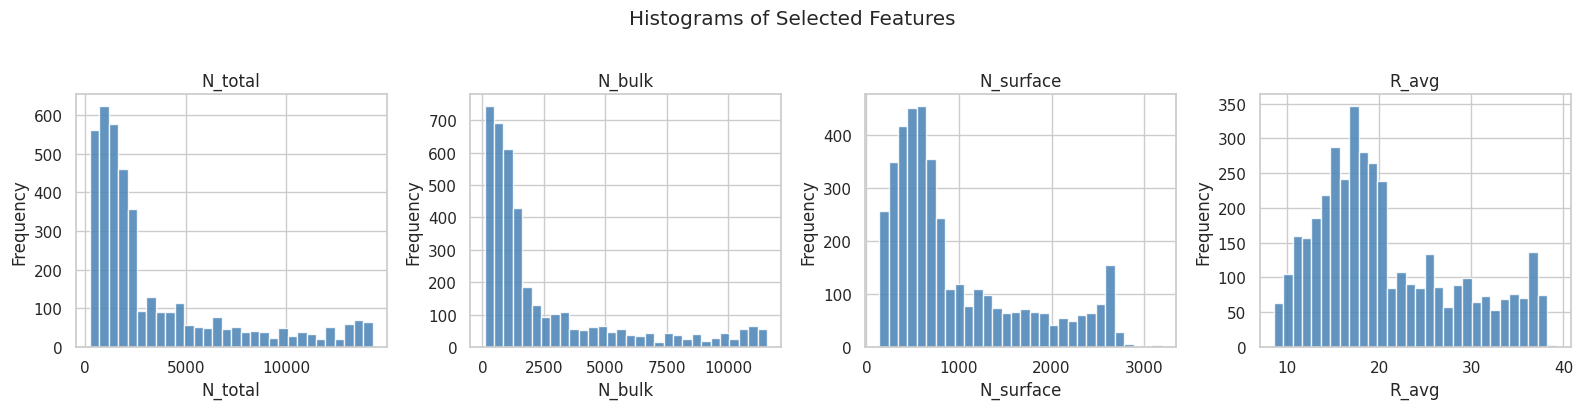

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, features):
    ax.hist(new_df[col], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Histograms of Selected Features", y=1.02)
plt.tight_layout()
plt.show()

## 5. Pairplot (scatter plots + histograms)

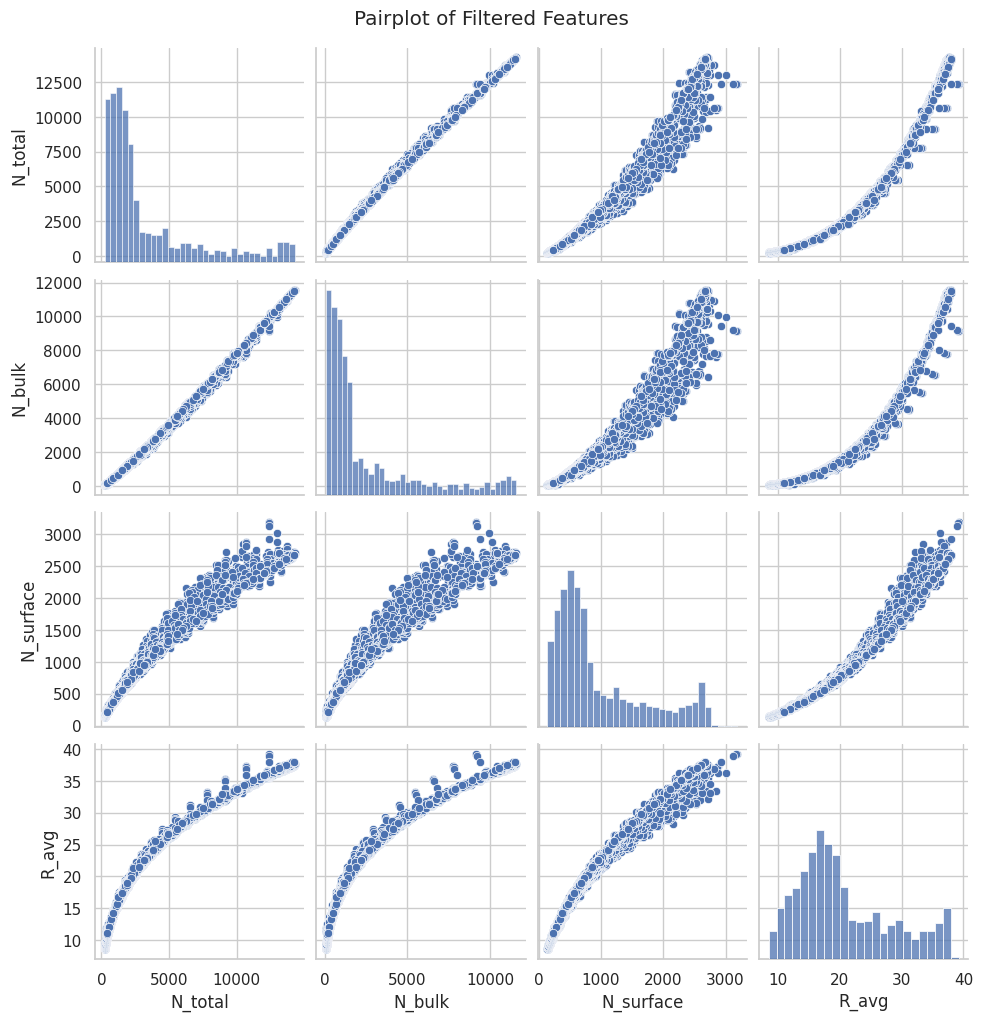

In [9]:
sns.pairplot(new_df)
plt.suptitle("Pairplot of Filtered Features", y=1.02)
plt.show()

## 6. Custom PairGrid
- **Diagonal:** histogram + kernel density estimate (KDE)
- **Upper:** bivariate histogram
- **Lower:** bivariate KDE

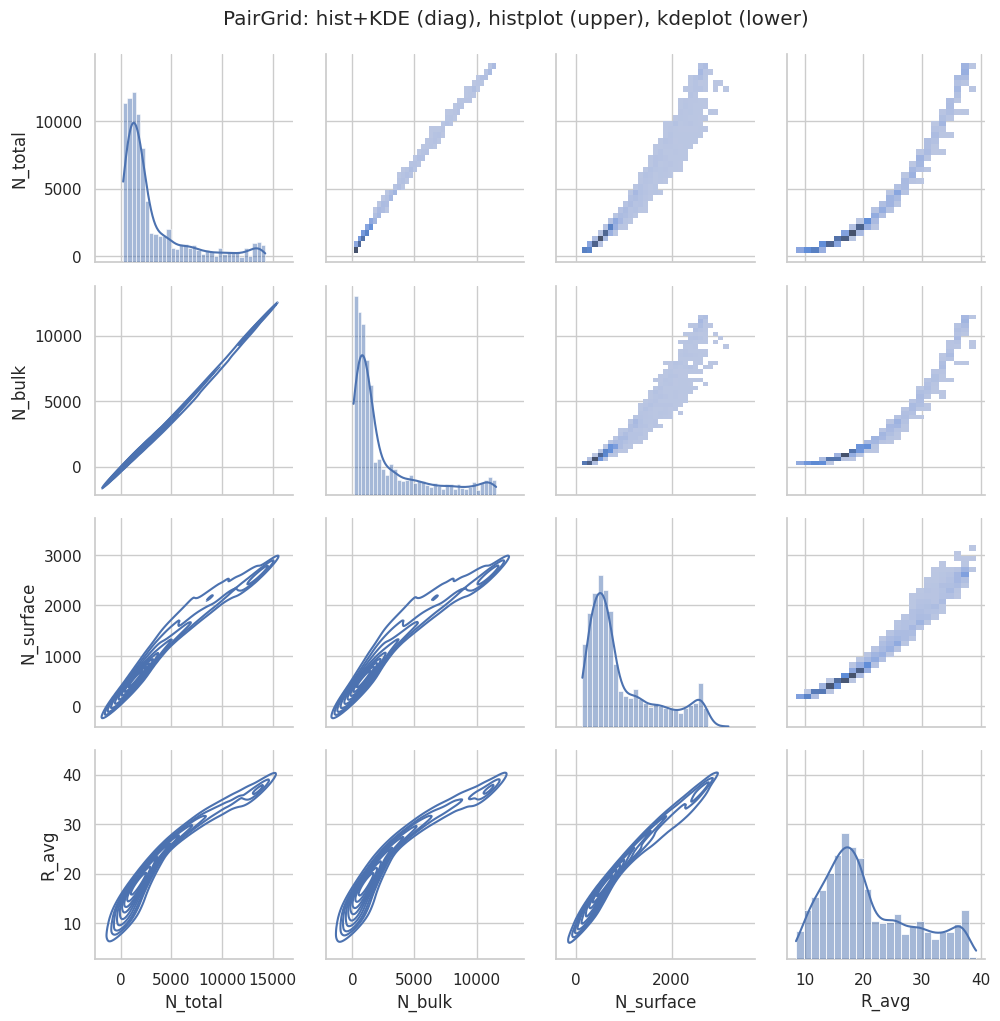

In [10]:
# new_df is the dataframe containing only the above mentioned 4 features.
g = sns.PairGrid(new_df)
g.map_upper(sns.histplot)  # bivariate histogram
g.map_diag(sns.histplot, kde=True)  # histogram + KDE on diagonal
g.map_lower(sns.kdeplot)  # bivariate KDE on lower half

plt.suptitle("PairGrid: hist+KDE (diag), histplot (upper), kdeplot (lower)", y=1.02)
plt.show()